In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

num_data_points = 500

mean_normal = [5, 10]
std_normal = [1, 2]

normal_data = np.random.normal(loc=mean_normal, scale=std_normal, size=(num_data_points, 2))
outliers = np.random.normal(loc=[20, 30], scale=[5,8], size=(50, 2))
data = np.vstack((normal_data, outliers))

print(f"Data shape: {data.shape}")

Data shape: (550, 2)


In [21]:
print(normal_data.mean(axis=0))
print(normal_data.std(axis=0))
print(outliers.mean(axis=0))
print(outliers.std(axis=0))

[ 5.0036012  10.07012582]
[0.96606702 1.9819481 ]
[21.79812608 29.68578888]
[4.12429918 8.11078135]


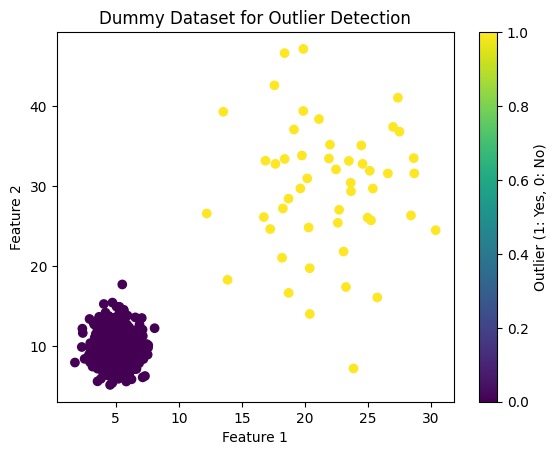

In [22]:
target = np.hstack([np.zeros(num_data_points), np.ones(50)])
# Create a DataFrame for the dataset
df = pd.DataFrame(data, columns=['Feature1', 'Feature2'])
df['Outlier'] = target.astype(int)

# Visualize the dataset
plt.scatter(df['Feature1'], df['Feature2']
, c=df['Outlier'], cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dummy Dataset for Outlier Detection')
plt.colorbar(label='Outlier (1: Yes, 0: No)')
plt.show()

In [24]:
from scipy import stats
# Apply Z-score method for outlier detection
z_scores = np.abs(stats.zscore(df[['Feature1', 'Feature2']]))
threshold = 3 # Adjust the threshold based on your preference
# Identify outliers based on the threshold
#outliers_zscore = df[(z_scores['Feature1'] > threshold) | (z_scores['Feature2'] > threshold)]

In [26]:
outliers_zscore = df[(z_scores[:, 0] > threshold) | (z_scores[:, 1] > threshold)]

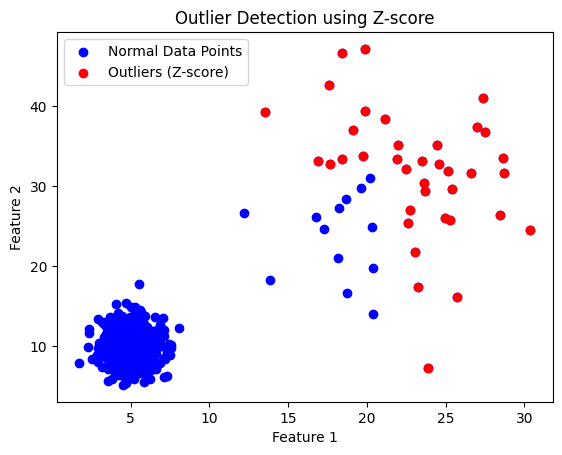

In [27]:
# Visualize the dataset with outliers detected by Z-score method
plt.scatter(df['Feature1'], df['Feature2']
, c='blue', label='Normal Data Points')
plt.scatter(outliers_zscore['Feature1']
, outliers_zscore['Feature2'], c='red', label='Outliers (Z-score)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Outlier Detection using Z-score')
plt.legend()
plt.show()

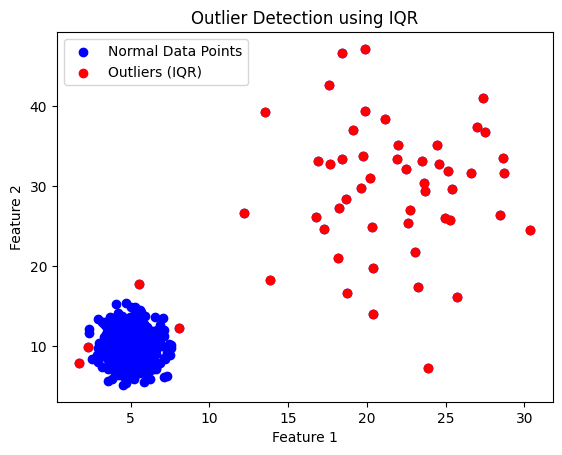

In [28]:
Q1 = df[['Feature1', 'Feature2']].quantile(0.25)
Q3 = df[['Feature1', 'Feature2']].quantile(0.75)
IQR = Q3 - Q1

outlier_range_lower = Q1 - 1.5 * IQR
outlier_range_upper = Q3 + 1.5 * IQR
outliers_iqr = df[(df['Feature1'] < outlier_range_lower['Feature1']) | (df['Feature1'] > outlier_range_upper['Feature1']) |
(df['Feature2'] < outlier_range_lower['Feature2']) | (df['Feature2'] > outlier_range_upper['Feature2'])]

plt.scatter(df['Feature1'], df['Feature2']
, c='blue', label='Normal Data Points')
plt.scatter(outliers_iqr['Feature1'], outliers_iqr['Feature2'], c='red', label='Outliers (IQR)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Outlier Detection using IQR')
plt.legend()
plt.show()

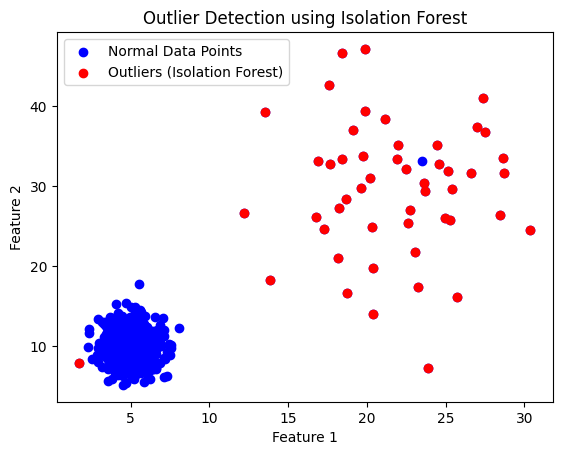

In [30]:
from sklearn.ensemble import IsolationForest
# Combine the features into a single array
X = df[['Feature1'
,
'Feature2']].values
# Fit the Isolation Forest model
isolation_forest = IsolationForest(contamination=0.09)
isolation_forest.fit(X)
# Predict outliers using the Isolation Forest model
outliers_isolation_forest = isolation_forest.predict(X)
outliers_isolation_forest = outliers_isolation_forest == -1
# Visualize the dataset with outliers detected by Isolation Forest method
plt.scatter(X[:, 0], X[:, 1], c='blue', label='Normal Data Points')
plt.scatter(X[outliers_isolation_forest,0], X[outliers_isolation_forest,1]
, c='red', label='Outliers (Isolation Forest)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Outlier Detection using Isolation Forest')
plt.legend()